In [24]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
from netCDF4 import Dataset
from regrid import regrid, regrid_fast
import pandas as pd
import cartopy
import matplotlib.animation as animation
from IPython import display
import cartopy.crs as ccrs
import tqdm
import pickle

In [25]:
conc12 = pickle.load(open('conc.p','rb'))
grid_d = Dataset('../aux_data/NSIDC0771_LatLon_PS_N12.5km_v1.1.nc')
lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
pslon = np.fliplr(np.rot90(np.rot90(lon)))
pslat = np.fliplr(np.rot90(np.rot90(lat)))
conc12.shape

/tmp/ipykernel_5647/3229833569.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])


(896, 608)

In [2]:
ssrd = pickle.load(open('ssrd.p','rb'))

In [8]:
ssrd.shape

(408, 896, 608)

(array([5.303155e+06, 4.983123e+06, 2.863239e+06, 1.228288e+06,
        4.974330e+05, 2.364740e+05, 1.253200e+05, 5.964200e+04,
        2.245600e+04, 2.494000e+03]),
 array([      0.        ,  241824.3466533 ,  483648.69330659,
         725473.03995989,  967297.38661318, 1209121.73326648,
        1450946.07991978, 1692770.42657307, 1934594.77322637,
        2176419.11987967, 2418243.46653296]),
 <BarContainer object of 10 artists>)

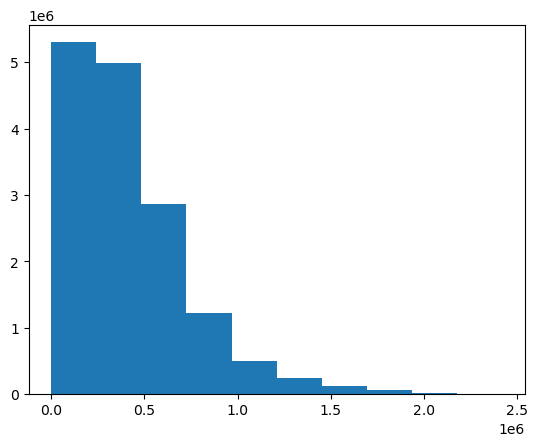

In [5]:
plt.hist(ssrd.flatten())

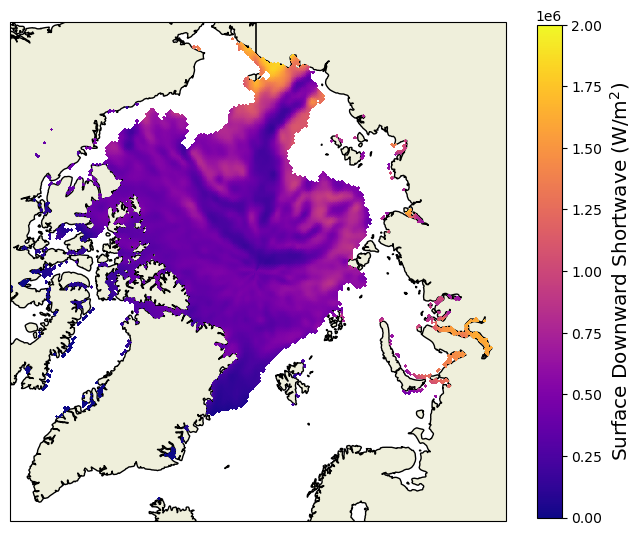

In [7]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=1)

m = ax.pcolormesh(pslon,pslat,
               ssrd[100],
               vmin=0,vmax=2e6,
                 transform=ccrs.PlateCarree(),cmap='plasma',
                 )

cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Surface Downward Shortwave (W/m$^2$)',fontsize='x-large')



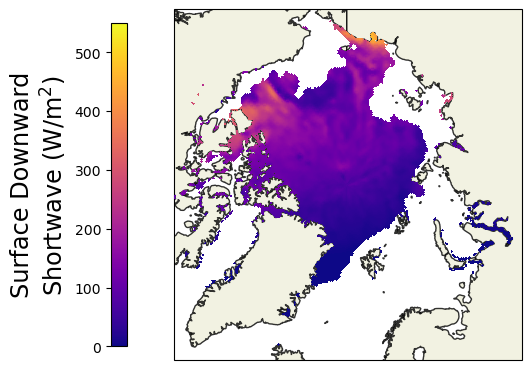

In [23]:
fig, ax1 = plt.subplots(1,1,figsize=(6,6),
                    subplot_kw={'projection':ccrs.NorthPolarStereo()})    

ax1.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=0,alpha=0.8)

ax1.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())

sd = ax1.pcolormesh(pslon,pslat,
                   ssrd[0]/3600,
                   vmin = 0, vmax = 550,
                   transform=ccrs.PlateCarree(),
                   cmap='plasma',
                   zorder=5,
                   alpha=1)

anno = ax1.annotate('',xycoords='axes fraction',xy=(0.99,0.99),ha='right',va='top',
                    fontsize='xx-large',zorder=7)


cbar1 = fig.colorbar(sd,
                    ax=ax1,
                    location='left',
                     shrink=0.7,
                   )

cbar1.set_label('Surface Downward\nShortwave (W/m$^2$)',fontsize='xx-large')

def animate(frame):

    sd.set_array(ssrd[frame]/3600)
    # date = dates[frame]
    # anno.set_text(date)

#######################################################

# fig.subplots_adjust(left=0.01, bottom=0, right=0.99, top=1, wspace=None, hspace=None)

ani = animation.FuncAnimation(fig,
                              animate,
                             frames= range(ssrd.shape[0]),
                             # frames= range(10),
                             )   


writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='RDCM'),
                                bitrate=1800)

ani.save('../figs/SW.gif', writer=writer)



# f = f'SW.mp4'
# writervideo = animation.FFMpegWriter(fps=30) 
# ani.save(f, writer=writervideo)